# Kartu-Verb project


The Kartu-Verb database comprises data pertaining to inflected Georgian verbs and their associated characteristics. The data is stored in a CSV file, with information organized into the following fields:

* form: The inflected form of a Georgian verb.
* tense_in_paradigm: The tense of the inflected form.
* person: The person of the inflected form (1st, 2nd, 3rd).
* number: The number of the inflected form (singular, plural).
* preverb: The preverb associated with the inflected form.
* pre2: The preradical of the inflected form.
* root: The root of the inflected form.
* sf2: The stem formant of the inflected form.
* caus_sf: The causative stem formant of the inflected form.
* ending: The ending of the inflected form.
* tsch_class: the Tschkhenkeli class to which the form belongs.
* morph_type: the morphology type to which the form belongs.
* id: Id in Clarino database to keep link to the corresponding croot.
* sub_id: Id in Clarino database to keep link to the corresponding verb paradigm.
* vn: Verbal Noun for the inflected form.

The objective of the project is to develop a model that can predict missing Verbal Noun based on the provided information, including the form, tense_in_paradigm, person, number, preverb, pre2, root, sf2, caus_sf, ending, tsch_class, morph_type, id and sub_id.

# Import Libraries

Import the usual libraries for pandas and plotting. We can import sklearn later on.

In [1]:
import pandas as pd
import numpy as np
import re
%config InlineBackend.figure_formats = ['svg'] #pdf,svg
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from datetime import datetime

## Get the Data

Read the Kartu-verb .csv file and assign it to a data frame named "kv".

In [2]:
kv = pd.read_csv('data_vn+withnotfullcroots', sep=';')

Check the head of kv.

In [3]:
kv.head(5)

,form,tense_in_paradigm,person,number,preverb,pre2,root,sf2,caus_sf,ending,tsch_class,morph_type,sub_id,id,vn
0,ვამხანაგობ,present,1,sg,-,ვ,ამხანაგ,ობ,-,-,MV,active,39-1,39,*ამხანაგობა
1,ჰამხანაგობ,present,2,sg,-,ჰ,ამხანაგ,ობ,-,-,MV,active,39-1,39,*ამხანაგობა
2,ამხანაგობ,present,2,sg,-,-,ამხანაგ,ობ,-,-,MV,active,39-1,39,*ამხანაგობა
3,ჰამხანაგობს,present,3,sg,-,ჰ,ამხანაგ,ობ,-,ს,MV,active,39-1,39,*ამხანაგობა
4,ამხანაგობს,present,3,sg,-,-,ამხანაგ,ობ,-,ს,MV,active,39-1,39,*ამხანაგობა


Display info about kv.

In [4]:
kv.info()

<class 'pandas.DataFrame'>
RangeIndex: 294665 entries, 0 to 294664
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   form               294665 non-null  str  
 1   tense_in_paradigm  294665 non-null  str  
 2   person             294665 non-null  int64
 3   number             294665 non-null  str  
 4   preverb            294665 non-null  str  
 5   pre2               294665 non-null  str  
 6   root               294665 non-null  str  
 7   sf2                294665 non-null  str  
 8   caus_sf            294665 non-null  str  
 9   ending             294665 non-null  str  
 10  tsch_class         294665 non-null  str  
 11  morph_type         294665 non-null  str  
 12  sub_id             294665 non-null  str  
 13  id                 294665 non-null  int64
 14  vn                 294665 non-null  str  
dtypes: int64(2), str(13)
memory usage: 33.7 MB


Create a function to plot Missing data Ration % in kv

In [5]:
def plot_nan(df: pd.DataFrame):
    if df.isnull().sum().sum() != 0:
        na_df = (df.isnull().sum() / len(df)) * 100
        print('How many elements are present in each files:')
        print(len(df)-df.isnull().sum())
        na_df = na_df.drop(na_df[na_df == 0].index).sort_values(ascending=False)
        missing_data = pd.DataFrame({'Missing Ratio %' :na_df})
        missing_data=round(missing_data,0)
        print(missing_data) 
        ax=missing_data.plot.barh(figsize=(10,3))
        ax.bar_label(ax.containers[0]) #rotation=270
        return ax
    else:
        print('No NAN found')

print('Kartu Verb Dataframe shape (rows,colomns) =',kv.shape)
#plot_nan(kv.replace('-',np.nan))

ax = plot_nan(kv.replace('-', np.nan))

now = datetime.now()
timestamp = now.strftime("%Y%m%d%H%M")
filename = f"output_missing_data_{timestamp}.svg"

ax.figure.tight_layout()
ax.figure.savefig(filename, format="svg")

plt.close(ax.figure)

Kartu Verb Dataframe shape (rows,colomns) = (294665, 15)
How many elements are present in each files:
form                 294665
tense_in_paradigm    294665
person               294665
number               294665
preverb              169378
pre2                 264752
root                 294665
sf2                  129237
caus_sf                4706
ending               287315
tsch_class           294665
morph_type           294665
sub_id               294665
id                   294665
vn                   294665
dtype: int64
         Missing Ratio %
caus_sf             98.0
sf2                 56.0
preverb             43.0
pre2                10.0
ending               2.0


Machine learning algorithms are not capable of directly processing textual data. In the case of the Kartu-Verbs database, which contains Georgian texts, it is necessary to convert the textual information into a numeric format. Additionally, it is important to handle empty values in the dataset, where empty values are denoted by a dash ("-").

To address these requirements, the following transformations were applied:
* Georgian strings were replaced with their equivalent binary representations.
* Empty values ("-") were replaced with 0.
* The 11 different values of "tense_in_paradigm" were replaced with a numerical range of [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11].
* The 28 different values of "tsch_class" were replaced with a numerical range of [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27].
* The 5 different values of "morph_type" were replaced with a numerical range of [0, 1, 2, 3, 4].

Note: The values of "tsch_class" were substituted with the provided numerical range for simplicity and ease of representation.

original: IV1, IV2, IV3, IV4, KT, KT (nur mit i.O.), KT (OR), MV, P1, P2, P3, RM1, RM1 (OR), RM2, RM2 (OR), RM3, RM3 (OR), RM4, RM4(OR),RP1,RP1(mit,RP1(ohnei.O.),RP1(OR),RP2,RP2, (OR),RP3,RP3(OR),RP4,RP4(OR),RP5,RP5(OR),RP6,RP6, (OR),RP7,RP7(ohnei.O.),RP7(OR),T1,T1(OR),T2,T2(OR),T3, T3 (nur mit i.O.), T3 (OR), T4, T4 (nur mit i.O.), T4 (OR), T5, T5 (nur mit i.O.), T5 (OR), T5 (OR) (nur mit i.O.), ZP1, ZP2, ZP3

substitution: IV1, IV2, IV3, IV4, KT, MV, P1, P2, P3, RM1, RM2, RM3, RM4, RP1, RP2, RP3, RP4, RP5, RP6, RP7, T1, T2, T3, T4, T5, ZP1, ZP2, ZP3


In [6]:
tense_map = {
    'present': 1, 'imperfect': 2, 'conj-present': 3, 'future': 4, 'conditional': 5,
    'conj-future': 6, 'aorist': 7, 'optative': 8, 'perfect': 9, 'pluperfect': 10, 'conj-perfect': 11
}

morph_map = {'-': 0, 'active': 1, 'causative': 2, 'passive': 3, 'stative-passive': 4}

tsch_map = {
    'IV1': 1, 'IV2': 2, 'IV3': 3, 'IV4': 4, 'KT': 5, 'MV': 6, 'P1': 7, 'P2': 8, 'P3': 9,
    'RM1': 10, 'RM2': 11, 'RM3': 12, 'RM4': 13, 'RP1': 14, 'RP2': 15, 'RP3': 16, 'RP4': 17,
    'RP5': 18, 'RP6': 19, 'RP7': 20,  'T1': 21, 'T2': 22, 'T3': 23, 'T4': 24, 'T5': 25,
    'ZP1': 26, 'ZP2': 27, 'ZP3': 28
}

number_map = {'sg': 1, 'pl': 2}

preverb_map = {
    '-': 0, 'ა': 1, 'ამო': 2, 'აღ': 3, 'აღმო': 4, 'გა': 5, 'გად': 6, 'გადა': 7, 'გადმო': 8,
    'გამო': 9, 'გან': 10, 'გარდ': 11, 'გარდა': 12, 'გარემო': 13, 'გარსშემო': 14, 'გარშემო': 15,
    'და': 16, 'დამო': 17, 'თანა': 18, 'იავარ': 19, 'მი': 20, 'მიმო': 21, 'მო': 22, 'უკუ': 23,
    'შე': 24, 'შემო': 25, 'შთა': 26, 'ჩა': 27, 'ჩამო': 28, 'ძალ': 29, 'წა': 30, 'წამო': 31,
    'წარ': 32, 'წარმო': 33, 'წინა': 34
}

sf2_map = {'-': 0, 'ავ': 1, 'ამ': 2, 'ე': 3, 'ებ': 4, 'ევ': 5, 'ვ': 6, 'ი': 7, 'მ': 8, 'ობ': 9, 'ოფ': 10}

caus_map = {'-': 0, 'ევინ': 1, 'ინ': 2}


#ეს მჭირდება მერე
kv['raw_sub_id'] = kv['sub_id'].copy()
kv['raw_id'] = kv['id'].copy()

kv = kv.copy()  # good idea if kv came from filtering

replace_dict = {
    'tense_in_paradigm': tense_map,
    'morph_type': morph_map,
    'tsch_class': tsch_map,
    'number': number_map,
    'preverb': preverb_map,
    'sf2': sf2_map,
    'caus_sf': caus_map,
    'pre2': {'-': '0'},
    'root': {'-': '0'},
    'ending': {'-': '0'},
    'vn': {'-': '0'},
}

with pd.option_context("future.no_silent_downcasting", True):
    kv = kv.replace(replace_dict)

# these columns are categorical codes, so make them numeric explicitly
num_cols = [
    'tense_in_paradigm',
    'morph_type',
    'tsch_class',
    'number',
    'preverb',
    'sf2',
    'caus_sf'
]

kv[num_cols] = kv[num_cols].apply(pd.to_numeric, errors='raise').astype('int64')

# these columns remain text-like identifiers
text_cols = ['pre2', 'root', 'ending', 'vn']
kv[text_cols] = kv[text_cols].astype('string')

# regex separately
kv['sub_id'] = (
    kv['sub_id']
    .astype('string')
    .str.replace(r'.*-', '', regex=True)
)


In [7]:
kv['sub_id'] = pd.to_numeric(kv['sub_id'], errors='raise').astype('int64')
#print(kv['sub_id'])

In the UTF-8 encoding scheme, Georgian characters are represented by three bytes. The first two bytes are redundant for the conversion process. To convert Georgian text into a numeric representation, we extract the last byte from each character and sum their decimal values. For this purpose, we created the following function.

In [8]:
def str2dec(x): #To sum last byte decimal versions for each character of a given string x
    s=0
    for i in x:
        s+=ord(i.encode('utf8')[-1:])
    return s

#kv[kv['ending'].isna()][['ending']].head(10)

Subsequently, we incorporated additional fields into the "kv" dataframe, specifically "formd", "preverbd", "pre2d", "rootd", "caus_sfd", "sf2d", and "endingd". These newly introduced fields correspond to the decimal representations of the original fields, namely "form", "preverb", "pre2", "root", "caus_sf", "sf2", and "ending". The purpose of including these fields is to store the converted decimal representations of the respective values.

In [9]:
#To convert a Georgian string into the sum of its characters' decimal representations,
kv['formd'] = kv['form'].apply(lambda x: str2dec(x))
kv['pre2d'] = kv['pre2'].apply(lambda x: str2dec(x))
kv['rootd'] = kv['root'].apply(lambda x: str2dec(x))
kv['endingd'] = kv['ending'].apply(lambda x: str2dec(x))
kv['vnd'] = kv['vn'].apply(lambda x: str2dec(x))

Let's encode the field "vn2d" by enumerating its values from 1 to N, and store this encoding information in a dictionary called "index_vn2."

In [10]:
index_vn = {}
vn_new_list = []

for i in kv['vn']:
    if i not in index_vn:
        index_vn[i] = len(index_vn)
    vn_new_list.append(index_vn[i])

kv['vnd']=vn_new_list

#print(index_vn)
filename = f"output_vn_index_{timestamp}.txt"
with open(filename,'w') as data:
    data.write(str(index_vn))

To facilitate further investigation, we can save the corresponding text and numeric representations for the "forms" and "verbal nouns" separately in individual files. This separation will allow for easier analysis and examination of the data.

In [11]:
filename = f"output_form_formd_{timestamp}.csv"
kv[['form','formd']].to_csv(filename,sep=',')
filename = f"output_vn_vnd_{timestamp}.csv"
kv[['vn','vnd']].to_csv(filename,sep=',')

In [12]:
kv.describe()

,tense_in_paradigm,person,number,preverb,sf2,caus_sf,tsch_class,morph_type,sub_id,id,raw_id,formd,pre2d,rootd,endingd,vnd
count,294665.000000,294665.000000,294665.000000,294665.000000,294665.000000,294665.000000,294665.000000,294665.000000,294665.000000,294665.000000,294665.000000,294665.000000,294665.000000,294665.000000,294665.000000,294665.000000
mean,6.248808,2.112463,1.531186,7.731376,1.894341,0.018000,14.402491,1.814467,25.888063,2059.900219,2059.900219,1584.826030,209.925461,537.729503,519.076823,250.425222
std,3.137606,0.813681,0.499027,9.993178,2.502208,0.147428,8.049219,0.893504,27.425140,1214.070507,1214.070507,458.701246,109.475591,211.782085,294.146656,137.672942
min,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,39.000000,39.000000,289.000000,48.000000,145.000000,48.000000,0.000000
25%,3.000000,1.000000,1.000000,0.000000,0.000000,0.000000,6.000000,1.000000,7.000000,904.000000,904.000000,1235.000000,148.000000,461.000000,299.000000,140.000000
50%,7.000000,2.000000,2.000000,1.000000,0.000000,0.000000,14.000000,1.000000,16.000000,2154.000000,2154.000000,1541.000000,163.000000,484.000000,451.000000,239.000000
75%,9.000000,3.000000,2.000000,16.000000,4.000000,0.000000,22.000000,3.000000,38.000000,3218.000000,3218.000000,1867.000000,294.000000,638.000000,744.000000,368.000000
max,11.000000,3.000000,2.000000,33.000000,9.000000,2.000000,28.000000,4.000000,222.000000,3844.000000,3844.000000,3803.000000,1075.000000,1394.000000,1687.000000,493.000000


In [13]:
kv.info()

<class 'pandas.DataFrame'>
RangeIndex: 294665 entries, 0 to 294664
Data columns (total 22 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   form               294665 non-null  str   
 1   tense_in_paradigm  294665 non-null  int64 
 2   person             294665 non-null  int64 
 3   number             294665 non-null  int64 
 4   preverb            294665 non-null  int64 
 5   pre2               294665 non-null  string
 6   root               294665 non-null  string
 7   sf2                294665 non-null  int64 
 8   caus_sf            294665 non-null  int64 
 9   ending             294665 non-null  string
 10  tsch_class         294665 non-null  int64 
 11  morph_type         294665 non-null  int64 
 12  sub_id             294665 non-null  int64 
 13  id                 294665 non-null  int64 
 14  vn                 294665 non-null  string
 15  raw_sub_id         294665 non-null  str   
 16  raw_id             294665 non-n

# Setting up the Data
* Create a new dataframe called "kn_n" where we will retain only the number representation of the data.
* Simplify the dataframe by renaming the "tense_in_paradigm" column to "tense" for the sake of simplicity and clarity.

In [14]:
# ეს მერე დამჭირდება
groups_raw_sub_id = kv['raw_sub_id'].copy()
groups_id = kv['raw_id'].copy()

cols = [
    'formd', 'tense_in_paradigm', 'person', 'number', 'preverb',
    'pre2d', 'rootd', 'sf2', 'caus_sf', 'endingd',
    'tsch_class', 'morph_type', 'sub_id', 'id', 'vnd'
]

kv_n = kv.loc[:, cols].copy()
kv_n.rename(columns={'tense_in_paradigm': 'tense'}, inplace=True) # just rename 'tense_in_paradigm' with 'tense' for simplicity

dtype_map = {
    'formd': 'uint16',
    'tense': 'uint8',
    'person': 'uint8',
    'number': 'uint8',
    'preverb': 'uint8',
    'pre2d': 'uint16',
    'rootd': 'uint16',
    'sf2': 'uint8',
    'caus_sf': 'uint8',
    'endingd': 'uint16',
    'tsch_class': 'uint8',
    'morph_type': 'uint8',
    'sub_id': 'uint16',
    'id': 'uint16',
    'vnd': 'uint16'
}

kv_n = kv_n.astype(dtype_map)


To free up Memory, you can delete the "kv" dataframe.

In [15]:
#del kv #შემდეგში დამჭირდება

In [16]:
kv_n.describe()

,formd,tense,person,number,preverb,pre2d,rootd,sf2,caus_sf,endingd,tsch_class,morph_type,sub_id,id,vnd
count,294665.000000,294665.000000,294665.000000,294665.000000,294665.000000,294665.000000,294665.000000,294665.000000,294665.000000,294665.000000,294665.000000,294665.000000,294665.000000,294665.000000,294665.000000
mean,1584.826030,6.248808,2.112463,1.531186,7.731376,209.925461,537.729503,1.894341,0.018000,519.076823,14.402491,1.814467,25.888063,2059.900219,250.425222
std,458.701246,3.137606,0.813681,0.499027,9.993178,109.475591,211.782085,2.502208,0.147428,294.146656,8.049219,0.893504,27.425140,1214.070507,137.672942
min,289.000000,1.000000,1.000000,1.000000,0.000000,48.000000,145.000000,0.000000,0.000000,48.000000,1.000000,1.000000,1.000000,39.000000,0.000000
25%,1235.000000,3.000000,1.000000,1.000000,0.000000,148.000000,461.000000,0.000000,0.000000,299.000000,6.000000,1.000000,7.000000,904.000000,140.000000
50%,1541.000000,7.000000,2.000000,2.000000,1.000000,163.000000,484.000000,0.000000,0.000000,451.000000,14.000000,1.000000,16.000000,2154.000000,239.000000
75%,1867.000000,9.000000,3.000000,2.000000,16.000000,294.000000,638.000000,4.000000,0.000000,744.000000,22.000000,3.000000,38.000000,3218.000000,368.000000
max,3803.000000,11.000000,3.000000,2.000000,33.000000,1075.000000,1394.000000,9.000000,2.000000,1687.000000,28.000000,4.000000,222.000000,3844.000000,493.000000


In [17]:
kv_n.info()

<class 'pandas.DataFrame'>
RangeIndex: 294665 entries, 0 to 294664
Data columns (total 15 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   formd       294665 non-null  uint16
 1   tense       294665 non-null  uint8 
 2   person      294665 non-null  uint8 
 3   number      294665 non-null  uint8 
 4   preverb     294665 non-null  uint8 
 5   pre2d       294665 non-null  uint16
 6   rootd       294665 non-null  uint16
 7   sf2         294665 non-null  uint8 
 8   caus_sf     294665 non-null  uint8 
 9   endingd     294665 non-null  uint16
 10  tsch_class  294665 non-null  uint8 
 11  morph_type  294665 non-null  uint8 
 12  sub_id      294665 non-null  uint16
 13  id          294665 non-null  uint16
 14  vnd         294665 non-null  uint16
dtypes: uint16(7), uint8(8)
memory usage: 6.2 MB


To reduce the memory usage of a variable, we consider changing its data type to a less memory-intensive alternative.

In [18]:
print(kv_n.dtypes)
print(kv_n['tense'].dtypes)

formd         uint16
tense          uint8
person         uint8
number         uint8
preverb        uint8
pre2d         uint16
rootd         uint16
sf2            uint8
caus_sf        uint8
endingd       uint16
tsch_class     uint8
morph_type     uint8
sub_id        uint16
id            uint16
vnd           uint16
dtype: object
uint8


We can examine the new dataframe.

In [19]:
kv_n.info()

<class 'pandas.DataFrame'>
RangeIndex: 294665 entries, 0 to 294664
Data columns (total 15 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   formd       294665 non-null  uint16
 1   tense       294665 non-null  uint8 
 2   person      294665 non-null  uint8 
 3   number      294665 non-null  uint8 
 4   preverb     294665 non-null  uint8 
 5   pre2d       294665 non-null  uint16
 6   rootd       294665 non-null  uint16
 7   sf2         294665 non-null  uint8 
 8   caus_sf     294665 non-null  uint8 
 9   endingd     294665 non-null  uint16
 10  tsch_class  294665 non-null  uint8 
 11  morph_type  294665 non-null  uint8 
 12  sub_id      294665 non-null  uint16
 13  id          294665 non-null  uint16
 14  vnd         294665 non-null  uint16
dtypes: uint16(7), uint8(8)
memory usage: 6.2 MB


In [20]:
print(kv_n)

filename = f"output_vnd_{timestamp}.csv"
kv_n.to_csv(filename, index=False, encoding="utf-8")

        formd  tense  person  number  preverb  pre2d  rootd  sf2  caus_sf  \
0        1514      1       1       1        0    149   1063    9        0   
1        1541      1       2       1        0    176   1063    9        0   
2        1365      1       2       1        0     48   1063    9        0   
3        1702      1       3       1        0    176   1063    9        0   
4        1526      1       3       1        0     48   1063    9        0   
...       ...    ...     ...     ...      ...    ...    ...  ...      ...   
294660   1097      7       2       1        0    653    444    0        0   
294661    937      1       1       1       24    301    320    0        0   
294662    788      1       2       1       24    152    320    0        0   
294663    937      4       1       1       24    301    320    0        0   
294664    788      4       2       1       24    152    320    0        0   

        endingd  tsch_class  morph_type  sub_id    id  vnd  
0            4

## Decision Tree Model - Solution

## Train Test Split

Now, we will proceed with the task of dividing our data into a training set and a testing set.

To accomplish this, we will use the functionality provided by the scikit-learn library. This allows us to easily split our data into two distinct sets: one for training our model and the other for evaluating its performance.

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X = kv_n.drop('vnd',axis=1)
y = kv_n['vnd']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)
#print(X_test)
#print(y)
#X_test.to_csv(r'X_test.txt', index=None, sep=';')

Import DecisionTreeClassifier

In [23]:
from sklearn.tree import DecisionTreeClassifier

Create an instance of DecisionTreeClassifier() called dtree and fit it to the training data.

In [24]:
dtree = DecisionTreeClassifier(
    random_state=42,
    max_depth=28
)  #(criterion="log_loss", splitter="random", max_depth=28); 

In [25]:
dtree.fit(X_train,y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",28
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at

## Predictions and Evaluation of Decision Tree
Create predictions from the test set and create a classification report and a confusion matrix.

In [26]:
predictions = dtree.predict(X_test)

In [27]:
from sklearn.metrics import classification_report,confusion_matrix

In [28]:
print(classification_report(y_test,predictions))

/opt/conda/envs/python3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       1.00      1.00      1.00       207
           2       1.00      1.00      1.00       136
           3       1.00      1.00      1.00        47
           4       1.00      1.00      1.00       180
           5       1.00      1.00      1.00        37
           6       1.00      1.00      1.00        42
           7       1.00      1.00      1.00        51
           8       1.00      1.00      1.00        68
           9       1.00      1.00      1.00        35
          10       1.00      1.00      1.00        24
          11       1.00      1.00      1.00       136
          12       1.00      1.00      1.00        37
          13       1.00      1.00      1.00       159
          14       1.00      1.00      1.00        30
          15       1.00      1.00      1.00        51
          16       1.00      1.00      1.00        34
          17       1.00    

/opt/conda/envs/python3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/envs/python3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### If precision is 0 for some classes

This is not an error. It means that some classes are difficult for the model to predict correctly. In particular, some classes may exist in y_test, but the model may not predict them even once.

Precision is calculated as:

precision = TP / (TP + FP)

If the model never predicts a given class, then TP + FP = 0, and precision cannot be calculated mathematically. In such cases, scikit-learn sets precision to 0.0 and raises an UndefinedMetricWarning. This behavior can be controlled using the zero_division parameter.

Although the overall weighted accuracy is very high, several rare verbal-noun classes are not predicted in the test set. For such classes, precision is undefined because the classifier produces no samples assigned to these labels. In the evaluation, these undefined precision values were set to 0 using zero_division=0. This mainly affects low-support classes and does not substantially change the weighted average performance. zero_division=0 parameter. This mainly affects low-support classes and does not substantially change the weighted average performance.

Which classes where not used to be predicted:

In [29]:
report = classification_report(
    y_test,
    predictions,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).T

y_test_s = pd.Series(y_test)
pred_s = pd.Series(predictions)

classes_in_test = np.unique(y_test_s)
classes_in_pred = np.unique(pred_s)

not_predicted_classes = np.setdiff1d(classes_in_test, classes_in_pred)

not_predicted_df = report_df.loc[
    report_df.index.isin(not_predicted_classes.astype(str))
].copy()

not_predicted_df.sort_values('support')

,precision,recall,f1-score,support
277,0.0,0.0,0.0,10.0
289,0.0,0.0,0.0,13.0
278,0.0,0.0,0.0,22.0
282,0.0,0.0,0.0,23.0
290,0.0,0.0,0.0,23.0
291,0.0,0.0,0.0,26.0
283,0.0,0.0,0.0,39.0
285,0.0,0.0,0.0,58.0


To store the clssificaion report in the file "report.txt"

In [30]:
report = classification_report(y_test,predictions)
report_path = "report.txt"
filename = f"output_report_{timestamp}.txt"
text_file = open(filename,"w")
n = text_file.write(report)
text_file.close()

/opt/conda/envs/python3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/envs/python3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/envs/python3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

In [31]:
print(confusion_matrix(y_test,predictions))
cm = confusion_matrix(y_test,predictions)

[[ 37   0   0 ...   0   0   0]
 [  0 207   0 ...   0   0   0]
 [  0   0 136 ...   0   0   0]
 ...
 [  0   0   0 ...   8   0   0]
 [  0   0   0 ...   0   3   0]
 [  0   0   0 ...   0   0  10]]


### Confusion matrix visualization

Top classes: [237, 363, 239, 66, 405, 332, 164, 401, 33, 21, 238, 48, 317, 77, 381, 49, 22, 178, 453, 411]
Added 50%-90% classes: []
Selected classes: [237, 363, 239, 66, 405, 332, 164, 401, 33, 21, 238, 48, 317, 77, 381, 49, 22, 178, 453, 411]
Number of selected classes: 20


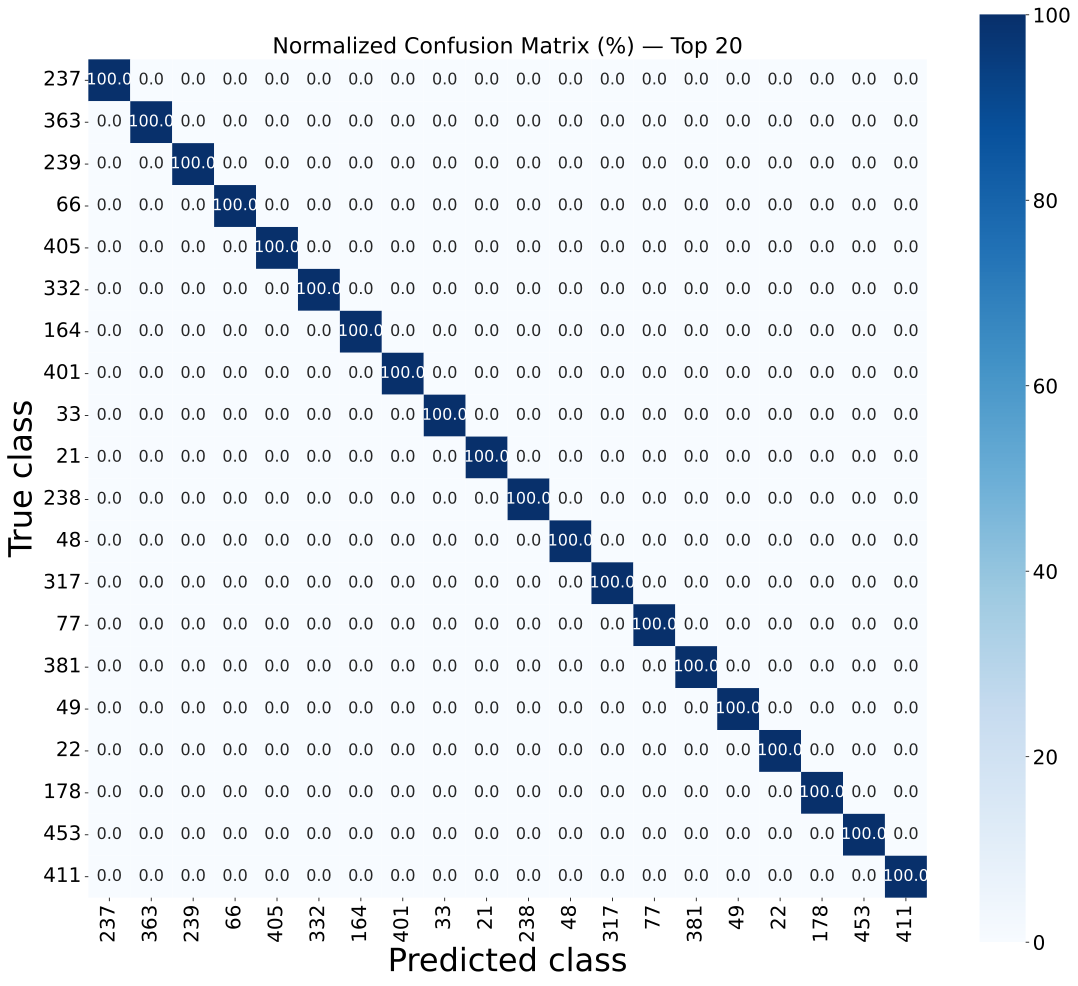

In [32]:
TOP_N = 20
MID_N = 0   # 50%-90%-ში არსებული დაახლოებით 5 კლასი

# prediction Series, რომ index დაემთხვეს y_test-ს
pred_series = pd.Series(predictions, index=y_test.index)

# 1) ყველაზე ხშირი TOP_N კლასი
top_classes = y_test.value_counts().head(TOP_N).index.tolist()

# 2) classification report ცხრილად
report_dict = classification_report(
    y_test,
    predictions,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).T

# მხოლოდ კლასები დავტოვოთ
class_report = report_df[
    report_df.index.str.isnumeric()
].copy()

class_report.index = class_report.index.astype(int)

# 3) ავიღოთ კლასები, სადაც f1-score არის 50%-დან 90%-მდე
mid_classes = class_report[
    (class_report['f1-score'] >= 0.50) &
    (class_report['f1-score'] <= 0.90)
].sort_values('f1-score').head(MID_N).index.tolist()

# 4) გავაერთიანოთ TOP_N + 50-90%-იანი კლასები
selected_classes = list(dict.fromkeys(top_classes + mid_classes))

print("Top classes:", top_classes)
print("Added 50%-90% classes:", mid_classes)
print("Selected classes:", selected_classes)
print("Number of selected classes:", len(selected_classes))

# 5) ავიღოთ მხოლოდ selected_classes-ის true rows
mask = y_test.isin(selected_classes)

y_test_sel = y_test[mask]
pred_sel = pred_series[mask]

cm_sel = confusion_matrix(
    y_test_sel,
    pred_sel,
    labels=selected_classes
)

# row-wise normalization
cm_sel_norm = cm_sel.astype("float") / cm_sel.sum(axis=1)[:, np.newaxis]
cm_sel_norm = np.nan_to_num(cm_sel_norm)

cm_sel_percent = cm_sel_norm * 100

plt.figure(figsize=(16, 14))

sns.heatmap(
    cm_sel_percent,
    cmap="Blues",
    annot=True,
    fmt=".1f",
    xticklabels=selected_classes,
    yticklabels=selected_classes,
    cbar=True,
    square=True,
    annot_kws={"size": 16}   # უჯრებში არსებული პროცენტები
)


plt.title(
    f"Normalized Confusion Matrix (%) — Top {TOP_N}",
    fontsize=22
)
plt.xlabel("Predicted class", fontsize=32)
plt.ylabel("True class", fontsize=32)

plt.xticks(rotation=90, fontsize=20)
plt.yticks(rotation=0, fontsize=20)

# colorbar-ის ფონტის გაზრდა
cbar = plt.gcf().axes[-1]
cbar.tick_params(labelsize=20)


# Vector format — recommended for the article
plt.savefig(
    "cm1.pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.02
)
# SVG vector format
plt.savefig(
    "cm1.svg",
    format="svg",
    bbox_inches="tight",
    pad_inches=0.02
)

# High-resolution image
plt.savefig(
    "cm1.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.02
)


plt.tight_layout()
plt.show()

Top classes: [237, 363, 239, 66, 405]
Added 50%-90% classes: [277, 278, 282, 283, 285, 289, 290, 291, 449, 468, 288, 467, 280, 279, 24]
Selected classes: [237, 363, 239, 66, 405, 277, 278, 282, 283, 285, 289, 290, 291, 449, 468, 288, 467, 280, 279, 24]
Number of selected classes: 20


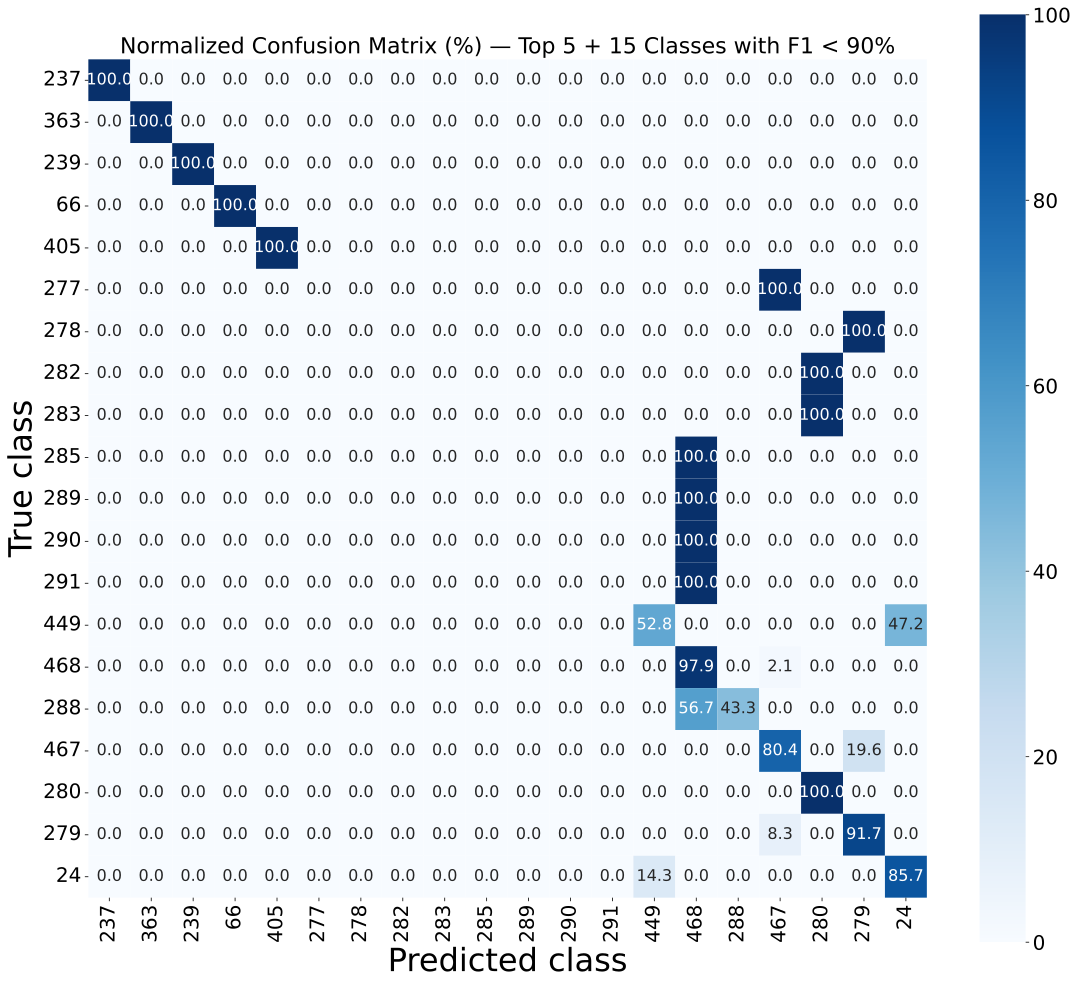

In [33]:
TOP_N = 5
MID_N = 15   # 50%-90%-ში არსებული დაახლოებით 5 კლასი

# prediction Series, რომ index დაემთხვეს y_test-ს
pred_series = pd.Series(predictions, index=y_test.index)

# 1) ყველაზე ხშირი TOP_N კლასი
top_classes = y_test.value_counts().head(TOP_N).index.tolist()

# 2) classification report ცხრილად
report_dict = classification_report(
    y_test,
    predictions,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).T

# მხოლოდ კლასები დავტოვოთ
class_report = report_df[
    report_df.index.str.isnumeric()
].copy()

class_report.index = class_report.index.astype(int)

# 3) ავიღოთ კლასები, სადაც f1-score არის 50%-დან 90%-მდე
mid_classes = class_report[
    #(class_report['f1-score'] >= 0.50) &
    (class_report['f1-score'] <= 0.90)
].sort_values('f1-score').head(MID_N).index.tolist()

# 4) გავაერთიანოთ TOP_N + 50-90%-იანი კლასები
selected_classes = list(dict.fromkeys(top_classes + mid_classes))

print("Top classes:", top_classes)
print("Added 50%-90% classes:", mid_classes)
print("Selected classes:", selected_classes)
print("Number of selected classes:", len(selected_classes))

# 5) ავიღოთ მხოლოდ selected_classes-ის true rows
mask = y_test.isin(selected_classes)

y_test_sel = y_test[mask]
pred_sel = pred_series[mask]

cm_sel = confusion_matrix(
    y_test_sel,
    pred_sel,
    labels=selected_classes
)

# row-wise normalization
cm_sel_norm = cm_sel.astype("float") / cm_sel.sum(axis=1)[:, np.newaxis]
cm_sel_norm = np.nan_to_num(cm_sel_norm)

cm_sel_percent = cm_sel_norm * 100

plt.figure(figsize=(16, 14))

sns.heatmap(
    cm_sel_percent,
    cmap="Blues",
    annot=True,
    fmt=".1f",
    xticklabels=selected_classes,
    yticklabels=selected_classes,
    cbar=True,
    square=True,
    annot_kws={"size": 16}   # უჯრებში არსებული პროცენტები
)

plt.title(
    #f"Normalized Confusion Matrix (%) — Top {TOP_N} + {MID_N} Classes with F1 50–90%",
    f"Normalized Confusion Matrix (%) — Top {TOP_N} + {MID_N} Classes with F1 < 90%",
    fontsize=22
)
plt.xlabel("Predicted class", fontsize=32)
plt.ylabel("True class", fontsize=32)

plt.xticks(rotation=90, fontsize=20)
plt.yticks(rotation=0, fontsize=20)

# colorbar-ის ფონტის გაზრდა
cbar = plt.gcf().axes[-1]
cbar.tick_params(labelsize=20)


# Vector format — recommended for the article
plt.savefig(
    "cm2.pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.02
)
# SVG vector format
plt.savefig(
    "cm2.svg",
    format="svg",
    bbox_inches="tight",
    pad_inches=0.02
)

# High-resolution image
plt.savefig(
    "cm2.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.02
)


plt.tight_layout()
plt.show()



## Decision Tree visualization

In [34]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

small_tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=101
)

small_tree.fit(X_train, y_train)

plt.figure(figsize=(28, 14))

plot_tree(
    small_tree,
    feature_names=X_train.columns.tolist(),
    class_names=None,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Simplified Decision Tree for Verbal Noun Prediction", fontsize=16)
plt.tight_layout()

plt.savefig("simplified_decision_tree.png", dpi=300, bbox_inches="tight")
plt.show()

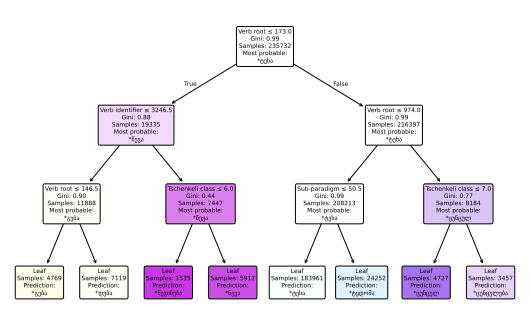

In [35]:
import re
import textwrap
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree, _tree

# Georgian characters
plt.rcParams["font.family"] = "DejaVu Sans"

# ==================================================
# 1. Train a small explanatory Decision Tree
# ==================================================
visual_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,          # compact tree with real leaves
    min_samples_leaf=20,
    random_state=101
)

visual_tree.fit(X_train, y_train)

# ==================================================
# 2. Create mapping:
# encoded verbal-noun ID -> original verbal noun
# ==================================================
id_to_verbal_noun = (
    kv[["vnd", "vn"]]
    .dropna()
    .drop_duplicates(subset="vnd")
    .assign(vnd=lambda dataframe: dataframe["vnd"].astype(int))
    .set_index("vnd")["vn"]
    .astype(str)
    .to_dict()
)

# ==================================================
# 3. Make feature names more readable
# ==================================================
feature_names_map = {
    "formd": "Inflected form",
    "tense": "Tense",
    "person": "Person",
    "number": "Number",
    "preverb": "Preverb",
    "pre2d": "Preradical",
    "rootd": "Verb root",
    "sf2": "Stem formant",
    "caus_sf": "Causative formant",
    "endingd": "Ending",
    "tsch_class": "Tschenkeli class",
    "morph_type": "Morphology type",
    "sub_id": "Sub-paradigm",
    "id": "Verb identifier"
}

feature_names_text = [
    feature_names_map.get(column, column)
    for column in X_train.columns
]

# ==================================================
# 4. Create an article-sized figure
# Suitable for full width of a two-column article
# ==================================================
fig, ax = plt.subplots(figsize=(7.2, 4.4))

annotations = plot_tree(
    visual_tree,
    feature_names=feature_names_text,
    class_names=None,
    node_ids=True,
    filled=True,
    rounded=True,
    impurity=False,
    proportion=False,
    fontsize=6,
    ax=ax
)

tree = visual_tree.tree_

# ==================================================
# 5. Replace the default node text
# Removes long numerical arrays
# ==================================================
for annotation in annotations:

    original_text = annotation.get_text()

    # Ignore True/False branch labels
    node_match = re.search(r"node #(\d+)", original_text)

    if node_match is None:
        continue

    node_id = int(node_match.group(1))

    samples = tree.n_node_samples[node_id]
    gini = tree.impurity[node_id]

    # Find the most probable class at this node
    node_class_values = np.asarray(
        tree.value[node_id]
    ).ravel()

    class_position = int(
        np.argmax(node_class_values)
    )

    encoded_class = visual_tree.classes_[class_position]

    verbal_noun = id_to_verbal_noun.get(
        int(encoded_class),
        f"Class {encoded_class}"
    )

    # Wrap long verbal nouns inside the node
    verbal_noun = textwrap.fill(
        str(verbal_noun),
        width=14
    )

    is_leaf = (
        tree.children_left[node_id] == _tree.TREE_LEAF
        and
        tree.children_right[node_id] == _tree.TREE_LEAF
    )

    if is_leaf:

        node_text = (
            "Leaf\n"
            f"Samples: {samples}\n"
            f"Prediction:\n{verbal_noun}"
        )

    else:

        feature_index = tree.feature[node_id]
        threshold = tree.threshold[node_id]
        feature_name = feature_names_text[feature_index]

        node_text = (
            f"{feature_name} ≤ {threshold:.1f}\n"
            f"Gini: {gini:.2f}\n"
            f"Samples: {samples}\n"
            f"Most probable:\n{verbal_noun}"
        )

    annotation.set_text(node_text)

# ==================================================
# 6. Final formatting
# ==================================================
ax.set_axis_off()

plt.tight_layout(pad=0.1)

# Vector format — recommended for the article
plt.savefig(
    "decision_tree_article.pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.02
)
# SVG vector format
plt.savefig(
    "decision_tree_article.svg",
    format="svg",
    bbox_inches="tight",
    pad_inches=0.02
)

# High-resolution image
plt.savefig(
    "decision_tree_article.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()

Decision Tree Feature Importance

   feature importance importance_percent
        id   0.453080             45.31%
     rootd   0.175998             17.60%
tsch_class   0.174098             17.41%
    sub_id   0.152841             15.28%
morph_type   0.024144              2.41%
       sf2   0.011305              1.13%
   caus_sf   0.004137              0.41%
   preverb   0.002663              0.27%
     tense   0.000871              0.09%
   endingd   0.000563              0.06%
     formd   0.000231              0.02%
     pre2d   0.000066              0.01%
    number   0.000003              0.00%


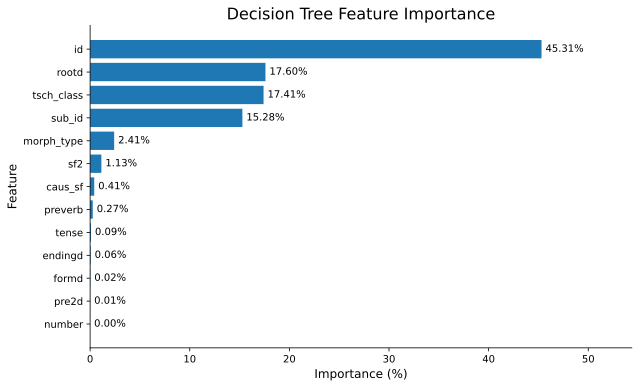

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Check that the Decision Tree has been trained
# --------------------------------------------------
if not hasattr(dtree, "feature_importances_"):
    raise ValueError(
        "The Decision Tree model has not been trained yet. "
        "Run dtree.fit(X_train, y_train) first."
    )

# --------------------------------------------------
# 2. Get feature names
# --------------------------------------------------
if hasattr(X_train, "columns"):
    feature_names = X_train.columns.tolist()
else:
    feature_names = [
        f"Feature {i}"
        for i in range(X_train.shape[1])
    ]

# --------------------------------------------------
# 3. Get and rank feature importance
# --------------------------------------------------
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": dtree.feature_importances_
})

importance_df["importance_percent"] = (
    importance_df["importance"] * 100
)

importance_df = (
    importance_df
    .sort_values(
        by="importance",
        ascending=False
    )
    .reset_index(drop=True)
)

# Keep only features actually used by the tree
importance_nonzero = importance_df[
    importance_df["importance"] > 0
].copy()

# --------------------------------------------------
# 4. Print the ranked feature-importance table
# --------------------------------------------------
print("Decision Tree Feature Importance\n")

print(
    importance_nonzero.to_string(
        index=False,
        formatters={
            "importance": "{:.6f}".format,
            "importance_percent": "{:.2f}%".format
        }
    )
)

# --------------------------------------------------
# 5. Create a horizontal bar chart
# --------------------------------------------------
plot_df = importance_nonzero.sort_values(
    by="importance_percent",
    ascending=True
)

fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.barh(
    plot_df["feature"],
    plot_df["importance_percent"]
)

# Add percentage labels
for bar, percentage in zip(
    bars,
    plot_df["importance_percent"]
):
    ax.text(
        bar.get_width() + 0.4,
        bar.get_y() + bar.get_height() / 2,
        f"{percentage:.2f}%",
        va="center",
        fontsize=10
    )

ax.set_title(
    "Decision Tree Feature Importance",
    fontsize=16
)

ax.set_xlabel(
    "Importance (%)",
    fontsize=12
)

ax.set_ylabel(
    "Feature",
    fontsize=12
)

# Leave space for labels after the bars
maximum_importance = plot_df[
    "importance_percent"
].max()

ax.set_xlim(
    0,
    maximum_importance * 1.20
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# --------------------------------------------------
# 6. Save the chart
# --------------------------------------------------
plt.savefig(
    "decision_tree_feature_importance.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.savefig(
    "decision_tree_feature_importance.svg",
    format="svg",
    bbox_inches="tight"
)

plt.savefig(
    "decision_tree_feature_importance.png",
    format="png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# Model Evaluation

To prepare the test data from a file, we have the "data_vn-.csv" file that includes all the fields except for the Verbal Noun. It is particularly intriguing to observe how our trained model performs in predicting the missing Verbal Nouns.

The file "data_vn-.csv" consists of 599813 lines and will serve as our test dataset for evaluating the model's ability to predict the missing Verbal Nouns.

### Common evaluation function
შემდეგი ფუნქცია ყველა შემდგომ ექსპერიმენტში ერთნაირად წვრთნის და აფასებს Decision Tree მოდელს. გამოიყენება max_depth=N, რათა ხის სიღრმე კონტროლირებადი იყოს.

In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def train_and_evaluate(X_train, X_test, y_train, y_test, title="Model evaluation"):
    dtree = DecisionTreeClassifier(
        random_state=101,
        max_depth=28 #39
        )
    
    dtree.fit(X_train, y_train)
    predictions = dtree.predict(X_test)
    
    print("=" * 80)
    print(title)
    print("=" * 80)
    
    print("Train accuracy:", accuracy_score(y_train, dtree.predict(X_train)))
    print("Test accuracy:", accuracy_score(y_test, predictions))
    print("Tree depth:", dtree.get_depth())
    print("Number of leaves:", dtree.get_n_leaves())
    
    print("\nClassification report:")
    print(classification_report(y_test, predictions, zero_division=0))
    
    cm = confusion_matrix(y_test, predictions)
    print("\nConfusion matrix shape:", cm.shape)
    print(cm)
    
    return dtree, predictions, cm

### 1) K-fold evaluation

In [38]:
from sklearn.model_selection import KFold

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=101
)

fold_results = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
    X_train_kf = X.iloc[train_idx]
    X_test_kf = X.iloc[test_idx]
    
    y_train_kf = y.iloc[train_idx]
    y_test_kf = y.iloc[test_idx]
    
    dtree = DecisionTreeClassifier(
        #max_depth=28,
        random_state=101)
    
    dtree.fit(X_train_kf, y_train_kf)
    
    train_acc = accuracy_score(y_train_kf, dtree.predict(X_train_kf))
    test_acc = accuracy_score(y_test_kf, dtree.predict(X_test_kf))
    
    fold_results.append({
        "fold": fold,
        "train_rows": len(train_idx),
        "test_rows": len(test_idx),
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "tree_depth": dtree.get_depth(),
        "n_leaves": dtree.get_n_leaves()
    })
    
    print("=" * 80)
    print(f"KFold - Fold {fold}")
    print("=" * 80)
    print("Train accuracy:", train_acc)
    print("Test accuracy:", test_acc)
    print("Tree depth:", dtree.get_depth())
    print("Number of leaves:", dtree.get_n_leaves())

kf_results_df = pd.DataFrame(fold_results)

print("\nKFold summary:")
print(kf_results_df)

print("\nMean test accuracy:", kf_results_df["test_accuracy"].mean())
print("Std test accuracy:", kf_results_df["test_accuracy"].std())

KFold - Fold 1
Train accuracy: 0.9997497157789355
Test accuracy: 0.9991515789116454
Tree depth: 39
Number of leaves: 800
KFold - Fold 2
Train accuracy: 0.9996860841973088
Test accuracy: 0.9994061052381518
Tree depth: 40
Number of leaves: 797
KFold - Fold 3
Train accuracy: 0.9996775999864252
Test accuracy: 0.9994061052381518
Tree depth: 38
Number of leaves: 794
KFold - Fold 4
Train accuracy: 0.9996648736700999
Test accuracy: 0.9994739789252202
Tree depth: 35
Number of leaves: 792
KFold - Fold 5
Train accuracy: 0.9997497157789355
Test accuracy: 0.9991515789116454
Tree depth: 38
Number of leaves: 780

KFold summary:
   fold  train_rows  test_rows  train_accuracy  test_accuracy  tree_depth  \
0     1      235732      58933        0.999750       0.999152          39   
1     2      235732      58933        0.999686       0.999406          40   
2     3      235732      58933        0.999678       0.999406          38   
3     4      235732      58933        0.999665       0.999474          

### Explanation

KFold ამოწმებს მოდელის სტაბილურობას 5-fold cross-validation-ით. მონაცემები 5-ჯერ იყოფა train/test ნაწილებად და ყოველ ჯერზე მოდელი თავიდან სწავლობს.

ეს პასუხობს კითხვას: თუ მონაცემებს რამდენიმე განსხვავებული random row-level split-ით გავყოფთ, მოდელი ყველა შემთხვევაში მსგავსად კარგად მუშაობს თუ არა?

თუმცა, ეს არის ჩვეულებრივი row-level split. ამიტომ ერთი და იგივე raw_sub_id ჯგუფის ფორმები შეიძლება მოხვდეს როგორც train-ში, ისე test-ში. ამ მიზეზით, KFold შედეგი უნდა განვმარტოთ როგორც within-database / row-level completion performance და არა როგორც generalization ახალ პარადიგმებზე.

### 2) GroupShuffleSplit

In [39]:
from sklearn.model_selection import GroupShuffleSplit

groups = groups_raw_sub_id

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=101
)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train_gss = X.iloc[train_idx]
X_test_gss = X.iloc[test_idx]

y_train_gss = y.iloc[train_idx]
y_test_gss = y.iloc[test_idx]

groups_train_gss = groups.iloc[train_idx]
groups_test_gss = groups.iloc[test_idx]

print("Train rows:", X_train_gss.shape[0])
print("Test rows:", X_test_gss.shape[0])

print("Train groups:", groups_train_gss.nunique())
print("Test groups:", groups_test_gss.nunique())

overlap = set(groups_train_gss) & set(groups_test_gss)
print("Group overlap:", len(overlap))

#მოდელის გაშვება
dtree_gss, pred_gss, cm_gss = train_and_evaluate(
    X_train_gss,
    X_test_gss,
    y_train_gss,
    y_test_gss,
    title="GroupShuffleSplit by raw_sub_id"
)

# დამატებით, ეს კოდი გაჩვენებს რამდენი vnd კლასი არის test-ში ისეთი, რომელიც train-ში საერთოდ არ იყო:
train_classes = set(y_train_gss)
test_classes = set(y_test_gss)

unseen_classes = test_classes - train_classes

print("VN classes in train:", len(train_classes))
print("VN classes in test:", len(test_classes))
print("VN classes in test but not in train:", len(unseen_classes))

rows_with_unseen_vn = y_test_gss.isin(unseen_classes).sum()

print("Rows with unseen VN in test:", rows_with_unseen_vn)
print("Rows with unseen VN in test (%):", round(rows_with_unseen_vn / len(y_test_gss) * 100, 2))

Train rows: 232814
Test rows: 61851
Train groups: 1876
Test groups: 470
Group overlap: 0
GroupShuffleSplit by raw_sub_id
Train accuracy: 0.9830508474576272
Test accuracy: 0.7132463500994325
Tree depth: 28
Number of leaves: 691

Classification report:
              precision    recall  f1-score   support

           2       1.00      1.00      1.00       116
           8       0.45      1.00      0.62       151
           9       0.00      0.00      0.00       188
          10       0.00      0.00      0.00         0
          11       0.00      0.00      0.00        96
          12       0.00      0.00      0.00         0
          13       0.87      0.58      0.70       424
          14       0.00      0.00      0.00         0
          15       0.18      0.66      0.28       106
          16       0.00      0.00      0.00       164
          17       1.00      1.00      1.00        82
          19       0.00      0.00      0.00         0
          21       1.00      1.00      1.00   

### Explanation

GroupShuffleSplit იყენებს raw_sub_id-ს ჯგუფად. ეს ნიშნავს, რომ ერთი და იგივე ზმნური პარადიგმის ყველა ფორმა მთლიანად ხვდება ან training set-ში, ან test set-ში.

თუ Group overlap არის 0, მაშინ train და test ნაწილებში ერთი და იგივე raw_sub_id არ მეორდება. ეს ამცირებს paradigm-level leakage-ის რისკს.

ეს ექსპერიმენტი ამოწმებს არა მხოლოდ არსებული ბაზის შიგნით გამოტოვებული სახელზმნების შევსებას, არამედ მოდელის უნარს იმუშაოს ახალ, training-ში არნახულ პარადიგმებზე.

დამატებით მოწმდება, რამდენი vn კლასი არის test set-ში ისეთი, რომელიც training set-ში საერთოდ არ გვხვდება. ასეთი კლასების პროგნოზირება Decision Tree-სთვის შეუძლებელია, რადგან supervised classifier ვერ აბრუნებს კლასს, რომელიც სწავლების დროს არ უნახავს. ამიტომ unseen VN classes-ის რაოდენობა მნიშვნელოვანია GroupShuffleSplit-ის შედეგის სწორად ინტერპრეტაციისთვის.


### 3) GroupKFold evaluation

In [40]:
from sklearn.model_selection import GroupKFold

groups = groups_raw_sub_id

gkf = GroupKFold(n_splits=5)

group_kfold_results = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups), start=1):
    X_train_gkf = X.iloc[train_idx]
    X_test_gkf = X.iloc[test_idx]
    
    y_train_gkf = y.iloc[train_idx]
    y_test_gkf = y.iloc[test_idx]
    
    groups_train_gkf = groups.iloc[train_idx]
    groups_test_gkf = groups.iloc[test_idx]
    
    dtree = DecisionTreeClassifier(
        #max_depth=28,
        random_state=101
    )
    
    dtree.fit(X_train_gkf, y_train_gkf)
    
    train_acc = accuracy_score(y_train_gkf, dtree.predict(X_train_gkf))
    test_acc = accuracy_score(y_test_gkf, dtree.predict(X_test_gkf))
    
    group_overlap = len(set(groups_train_gkf) & set(groups_test_gkf))
    
    group_kfold_results.append({
        "fold": fold,
        "train_rows": len(train_idx),
        "test_rows": len(test_idx),
        "train_groups": groups_train_gkf.nunique(),
        "test_groups": groups_test_gkf.nunique(),
        "group_overlap": group_overlap,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "tree_depth": dtree.get_depth(),
        "n_leaves": dtree.get_n_leaves()
    })
    
    print("=" * 80)
    print(f"GroupKFold - Fold {fold}")
    print("=" * 80)
    print("Train accuracy:", train_acc)
    print("Test accuracy:", test_acc)
    print("Tree depth:", dtree.get_depth())
    print("Number of leaves:", dtree.get_n_leaves())
    print("Group overlap:", group_overlap)

group_kfold_results_df = pd.DataFrame(group_kfold_results)

print("\nGroupKFold summary:")
print(group_kfold_results_df)

print("\nMean test accuracy:", group_kfold_results_df["test_accuracy"].mean())
print("Std test accuracy:", group_kfold_results_df["test_accuracy"].std())

GroupKFold - Fold 1
Train accuracy: 0.9995418526122886
Test accuracy: 0.7751344747425042
Tree depth: 40
Number of leaves: 747
Group overlap: 0
GroupKFold - Fold 2
Train accuracy: 0.9995418487252365
Test accuracy: 0.7474336133027912
Tree depth: 41
Number of leaves: 737
Group overlap: 0
GroupKFold - Fold 3
Train accuracy: 0.9995418526122886
Test accuracy: 0.7868426857617973
Tree depth: 36
Number of leaves: 722
Group overlap: 0
GroupKFold - Fold 4
Train accuracy: 0.9995418545557898
Test accuracy: 0.7720593226091088
Tree depth: 41
Number of leaves: 726
Group overlap: 0
GroupKFold - Fold 5
Train accuracy: 1.0
Test accuracy: 0.7638125296952419
Tree depth: 38
Number of leaves: 638
Group overlap: 0

GroupKFold summary:
   fold  train_rows  test_rows  train_groups  test_groups  group_overlap  \
0     1      235732      58933          1879          467              0   
1     2      235730      58935          1878          468              0   
2     3      235732      58933          1875       

### Explanation

GroupKFold არის KFold-ის უფრო მკაცრი ვარიანტი. ის ასევე აკეთებს 5-fold cross-validation-ს, მაგრამ იცავს ჯგუფებს: ერთი და იგივე raw_sub_id არასდროს ხვდება ერთდროულად train-სა და test-ში.

ამიტომ GroupKFold უკეთ ამოწმებს მოდელის generalization-ს ახალ პარადიგმებზე. თუ KFold-ში accuracy ძალიან მაღალია, ხოლო GroupKFold-ში მნიშვნელოვნად დაბალია, ეს მიუთითებს, რომ row-level split-ში შედეგი ნაწილობრივ დამოკიდებული იყო paradigm-level leakage-ზე.

## Comparison summary

In [41]:
summary = pd.DataFrame({
    "method": [
        "KFold",
        "GroupKFold"
    ],
    "mean_test_accuracy": [
        kf_results_df["test_accuracy"].mean(),
        group_kfold_results_df["test_accuracy"].mean()
    ],
    "std_test_accuracy": [
        kf_results_df["test_accuracy"].std(),
        group_kfold_results_df["test_accuracy"].std()
    ]
})

print(summary)

       method  mean_test_accuracy  std_test_accuracy
0       KFold            0.999318           0.000154
1  GroupKFold            0.769057           0.014640


### ეს ცხრილი ადარებს ორ შეფასებას:

KFold აჩვენებს, რამდენად სტაბილურად ავსებს Decision Tree მოდელი გამოტოვებულ სახელზმნებს მონაცემთა ბაზის შიგნით, როცა train და test შემთხვევით row-ებად იყოფა.

GroupShuffleSplit და GroupKFold ამოწმებს უფრო რთულ ამოცანას: შეუძლია თუ არა მოდელს ისეთი raw_sub_id პარადიგმებისთვის სახელზმნის პროგნოზირება, რომლებიც training data-ში საერთოდ არ ყოფილა.

# Prepare test data from a file

To prepare the test data from a file, we have the "data_vn-.csv" file that includes all the fields except for the Verbal Noun. It is particularly intriguing to observe how our trained model performs in predicting the missing Verbal Nouns.

The file "data_vn-.csv" consists of 599813 lines and will serve as our test dataset for evaluating the model's ability to predict the missing Verbal Nouns.

## Get the Data
Read in the "data_vn-.csv" file and set it to a data frame called kv.

In [42]:
X_test2 = pd.read_csv('data_vn-', sep=';')

Check the head of the kv dataframe.

In [43]:
#print(X_test2)
Solution = X_test2.copy()

In [44]:
X_test2.info()

<class 'pandas.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   form               99999 non-null  str  
 1   tense_in_paradigm  99999 non-null  str  
 2   person             99999 non-null  int64
 3   number             99999 non-null  str  
 4   preverb            99999 non-null  str  
 5   pre2               99999 non-null  str  
 6   root               99999 non-null  str  
 7   sf2                99999 non-null  str  
 8   caus_sf            99999 non-null  str  
 9   ending             99999 non-null  str  
 10  tsch_class         99999 non-null  str  
 11  morph_type         99999 non-null  str  
 12  sub_id             99999 non-null  str  
 13  id                 99999 non-null  int64
 14  vn                 99999 non-null  str  
dtypes: int64(2), str(13)
memory usage: 11.4 MB


To prepare the data, we will proceed with converting the textual information into a numeric representation. This conversion is necessary to enable the utilization of machine learning algorithms that operate on numerical data.

In [45]:
# If X_test2 came from filtering, make it a real independent df:
X_test2 = X_test2.copy()

tense_map = {
    'present': 1, 'imperfect': 2, 'conj-present': 3, 'future': 4, 'conditional': 5,
    'conj-future': 6, 'aorist': 7, 'optative': 8, 'perfect': 9, 'pluperfect': 10, 'conj-perfect': 11
}
morph_map = {'-': 0, 'active': 1, 'causative': 2, 'passive': 3, 'stative-passive': 4}
tsch_map = {
    'IV1': 1, 'IV2': 2, 'IV3': 3, 'IV4': 4, 'KT': 5, 'MV': 6, 'P1': 7, 'P2': 8, 'P3': 9,
    'RM1': 10, 'RM2': 11, 'RM3': 12, 'RM4': 13,
    'RP1': 14, 'RP2': 15, 'RP3': 16, 'RP4': 17, 'RP5': 18, 'RP6': 19, 'RP7': 20,
    'T1': 21, 'T2': 22, 'T3': 23, 'T4': 24, 'T5': 25,
    'ZP1': 26, 'ZP2': 27, 'ZP3': 28
}
number_map = {'sg': 1, 'pl': 2}
preverb_map = {
    '-': 0, 'ა': 1, 'ამო': 2, 'აღ': 3, 'აღმო': 4, 'გა': 5, 'გად': 6, 'გადა': 7, 'გადმო': 8,
    'გამო': 9, 'გან': 10, 'გარდ': 11, 'გარდა': 12, 'გარემო': 13, 'გარსშემო': 14, 'გარშემო': 15,
    'და': 16, 'დამო': 17, 'თანა': 18, 'იავარ': 19, 'მი': 20, 'მიმო': 21, 'მო': 22, 'უკუ': 23,
    'შე': 24, 'შემო': 25, 'შთა': 26, 'ჩა': 27, 'ჩამო': 28, 'ძალ': 29, 'წა': 30, 'წამო': 31,
    'წარ': 32, 'წარმო': 33, 'წინა': 34,
    'გარდმო': 35, 'ზეწამო': 36, 'იძულებულ': 37, 'ნათელ': 38, 'სრულ': 39, 'უარ': 40,
    'უგულებელ': 41, 'უვნებელ': 42, 'უზრუნველ': 43, 'უკვდავ': 44, 'უჩინარ': 45, 'ღაღად': 46,
    'შეურაცხ': 47, 'ცხად': 48, 'ხელ': 49, 'წინააღ': 50
}
sf2_map = {'-': 0, 'ავ': 1, 'ამ': 2, 'ე': 3, 'ებ': 4, 'ევ': 5, 'ვ': 6, 'ი': 7, 'მ': 8, 'ობ': 9, 'ოფ': 10}
caus_map = {'-': 0, 'ევინ': 1, 'ინ': 2}


replace_dict_test = {
    'tense_in_paradigm': tense_map,
    'morph_type': morph_map,
    'tsch_class': tsch_map,
    'number': number_map,
    'preverb': preverb_map,
    'sf2': sf2_map,
    'caus_sf': caus_map,
    'pre2': {'-': '0'},
    'root': {'-': '0'},
    'ending': {'-': '0'},
}
with pd.option_context("future.no_silent_downcasting", True):
    X_test2 = X_test2.replace(replace_dict_test)


# sub_id regex + numeric conversion
X_test2['sub_id'] = (
    X_test2['sub_id']
      .astype(str)
      .str.replace(r'.*-', '', regex=True)
)
X_test2['sub_id'] = pd.to_numeric(X_test2['sub_id'], errors='coerce')

# Optional: force numeric columns to numeric dtype (future-proof)
num_cols = ['tense_in_paradigm','morph_type','tsch_class','number','preverb','sf2','caus_sf']
X_test2[num_cols] = X_test2[num_cols].apply(pd.to_numeric, errors='raise').astype('Int64')

In [46]:
X_test2['formd'] = X_test2['form'].apply(lambda x: str2dec(x))
X_test2['pre2d'] = X_test2['pre2'].apply(lambda x: str2dec(x))
X_test2['rootd'] = X_test2['root'].apply(lambda x: str2dec(x))
X_test2['endingd'] = X_test2['ending'].apply(lambda x: str2dec(x))

In [47]:
X_test2.info()

<class 'pandas.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   form               99999 non-null  str  
 1   tense_in_paradigm  99999 non-null  Int64
 2   person             99999 non-null  int64
 3   number             99999 non-null  Int64
 4   preverb            99999 non-null  Int64
 5   pre2               99999 non-null  str  
 6   root               99999 non-null  str  
 7   sf2                99999 non-null  Int64
 8   caus_sf            99999 non-null  Int64
 9   ending             99999 non-null  str  
 10  tsch_class         99999 non-null  Int64
 11  morph_type         99999 non-null  Int64
 12  sub_id             99999 non-null  int64
 13  id                 99999 non-null  int64
 14  vn                 99999 non-null  str  
 15  formd              99999 non-null  int64
 16  pre2d              99999 non-null  int64
 17  rootd              9999

In [48]:
X_test2 = X_test2.loc[:,['formd','tense_in_paradigm','person','number','preverb','pre2d','rootd','sf2','caus_sf','endingd','tsch_class','morph_type','sub_id','id']]
X_test2.rename(columns={'tense_in_paradigm':'tense'}, inplace=True) # just rename 'tense_in_paradigm' with 'tense' for simplicity

In [49]:
X_test2[X_test2.columns[0]]=X_test2.loc[:,'formd'].astype('int16')
X_test2[X_test2.columns[1]]=X_test2.loc[:,'tense'].astype('byte')
X_test2[X_test2.columns[2]]=X_test2.loc[:,'person'].astype('byte')
X_test2[X_test2.columns[3]]=X_test2.loc[:,'number'].astype('byte')
X_test2[X_test2.columns[4]]=X_test2.loc[:,'preverb'].astype('byte')
X_test2[X_test2.columns[5]]=X_test2.loc[:,'pre2d'].astype('int16')
X_test2[X_test2.columns[6]]=X_test2.loc[:,'rootd'].astype('int16')
X_test2[X_test2.columns[7]]=X_test2.loc[:,'sf2'].astype('byte')
X_test2[X_test2.columns[8]]=X_test2.loc[:,'caus_sf'].astype('byte')
X_test2[X_test2.columns[9]]=X_test2.loc[:,'endingd'].astype('int16')
X_test2[X_test2.columns[10]]=X_test2.loc[:,'tsch_class'].astype('byte')
X_test2[X_test2.columns[11]]=X_test2.loc[:,'morph_type'].astype('byte')
X_test2[X_test2.columns[12]]=X_test2.loc[:,'sub_id'].astype('int16')
X_test2[X_test2.columns[13]]=X_test2.loc[:,'id'].astype('int16')

In [50]:
X_test2.info()

<class 'pandas.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   formd       99999 non-null  int16
 1   tense       99999 non-null  int8 
 2   person      99999 non-null  int8 
 3   number      99999 non-null  int8 
 4   preverb     99999 non-null  int8 
 5   pre2d       99999 non-null  int16
 6   rootd       99999 non-null  int16
 7   sf2         99999 non-null  int8 
 8   caus_sf     99999 non-null  int8 
 9   endingd     99999 non-null  int16
 10  tsch_class  99999 non-null  int8 
 11  morph_type  99999 non-null  int8 
 12  sub_id      99999 non-null  int16
 13  id          99999 non-null  int16
dtypes: int16(6), int8(8)
memory usage: 1.9 MB


In [51]:
# თუ preverb-ში data_vn- ფაილს აქვს ისეთი მნიშვნელობები, რომლებიც თქვენს preverb_map-ში არ არის, errors='raise' შეცდომას მოგვცემს. ეს კარგია, რადგან მაშინ ზუსტად დავინახავთ, რომ mapping-ს აკლია რომელიმე ზმნისწინი.
print(X_test2.isna().sum())
print(X_test2.head())

formd         0
tense         0
person        0
number        0
preverb       0
pre2d         0
rootd         0
sf2           0
caus_sf       0
endingd       0
tsch_class    0
morph_type    0
sub_id        0
id            0
dtype: int64
   formd  tense  person  number  preverb  pre2d  rootd  sf2  caus_sf  endingd  \
0   1649      1       1       1        0    293   1063    4        0       48   
1   1500      1       2       1        0    144   1063    4        0       48   
2   1661      1       3       1        0    144   1063    4        0      161   
3   1800      1       1       2        0    293   1063    4        0      151   
4   1651      1       2       2        0    144   1063    4        0      151   

   tsch_class  morph_type  sub_id  id  
0          21           1       8  39  
1          21           1       8  39  
2          21           1       8  39  
3          21           1       8  39  
4          21           1       8  39  


## Predictions and Evaluation of Decision Tree
Generate predictions from the test set and then create a classification report and a confusion matrix to evaluate the performance of the model.

In [52]:
predictions2 = dtree.predict(X_test2)

In [53]:
print(predictions2)

filename = f"output_predictions2_{timestamp}.txt"

with open(filename, 'w') as f:
    for line in predictions2:
        f.write(f"{line}\n")

[  1   1   1 ... 453 453 453]


After generating predictions from the test set, we will proceed to decode the numeric predictions back into their original Georgian text representations. This step allows us to interpret and analyze the model's outputs in a more understandable and meaningful manner. By converting the numeric predictions back to Georgian text, we can gain insights into the predicted outcomes and assess the model's performance in a linguistically meaningful context.

In [54]:
tmppd = pd.DataFrame({'vn': predictions2})
#print(tmppd)
#To reverse index_vn2 - swap keys:values.
index_vn_rev = {i: j for j, i in index_vn.items()}
#print(index_vn)
Solution['vn'] = tmppd.replace(index_vn_rev)
#print(Solution)

In [55]:
filename = f"output_solution{timestamp}.csv"
Solution.to_csv(filename, index=False, sep=';')

# Conclusion

The decision tree model has demonstrated excellent predictive capabilities. We conducted multiple runs of the model on the same dataset, each time using a different random_state parameter for the training and testing data split. Remarkably, in all runs, the model consistently produced identical results.

The model provides predictions with 98-99% as detailed in the **output_report.txt** file. These probabilities offer insights into the model's confidence levels for each prediction.

The corresponding outcomes can be accessed in the **output_solution.csv** file, which presents the predicted results derived from the decision tree model.